In [166]:
from __future__ import division
import pandas as pd
import numpy as np
import time
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

from matplotlib.ticker import FormatStrFormatter

import scipy.stats as sstat
import scipy.signal as ssig
import h5py
from mpl_toolkits.mplot3d import Axes3D
import os
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA as sklearnPCA
import re

# import ephys_unit_analysis as ena    # I may not be using this anymore!
import mz_ephys_unit_analysis as mz_ena

#import resampy
import fnmatch
import seaborn as sns
%matplotlib inline
%load_ext autoreload
%autoreload 2
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['font.sans-serif']=['Arial', 'Helvetica','Bitstream Vera Sans', 'DejaVu Sans', 'Lucida Grande', 
                                 'Verdana', 'Geneva', 'Lucid', 'Avant Garde', 'sans-serif']  

sns.despine()

# for publication quality plots, not bar graphs, use this: 
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple' ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    # optional, makes markers bigger, too, axes.linewidth doesn't seem to work
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
        'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
        'axes.linewidth':2.5, 'lines.linewidth': 2.5,
        'xtick.color': 'black', 'ytick.color': 'black', 
        'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<Figure size 432x288 with 0 Axes>

# Load the probe geometry

In [167]:
probe = 'Neuropixels'
channel_groups = mz_ena.get_channel_depth(probe)

# Normal loading .npy files
The recording folder has to have the "cluster_group.tsv" file from the kilosort output

In [168]:
root_files = []
matches = [] # list of experiment folders
source_folder = r"D:\mz_Data\RECORDING_DATA\SORT_neuropixels" #this is the outermost folder that has Kilosort/Phy files in it

for root, dirnames, filenames in os.walk(source_folder):
    for filename in fnmatch.filter(filenames, '*rez.mat'):
        for filename in fnmatch.filter(filenames, '*cluster_group.tsv'):
            if (str('pre') in root) or (str('post') in root) or (str('cont') in root):
                matches.append(os.path.join(root, filename))
                root_files.append(root)
                print ('Root:   ' + root)

print('\nIMPORTANT: This has "cluster_group.tsv" already appended to the matches list')
print ('How many files?',len(matches))

Root:   D:\mz_Data\RECORDING_DATA\SORT_neuropixels\check_cont50_RH_CC082261_HP32_2021-06-28_11-22-26
Root:   D:\mz_Data\RECORDING_DATA\SORT_neuropixels\check_cont50_RH_CC082261_HP42_2021-06-28_12-30-15
Root:   D:\mz_Data\RECORDING_DATA\SORT_neuropixels\drift_post50_RH_CC067492_HP11_2021-06-04_11-48-00
Root:   D:\mz_Data\RECORDING_DATA\SORT_neuropixels\drift_post50_RH_CC067492_HP21_2021-06-04_11-55-15
Root:   D:\mz_Data\RECORDING_DATA\SORT_neuropixels\drift_pre50_RH_CC082261_HP20_2021-06-28_11-08-28
Root:   D:\mz_Data\RECORDING_DATA\SORT_neuropixels\drift_pre50_RH_CC082261_HP30_2021-06-28_11-20-04
Root:   D:\mz_Data\RECORDING_DATA\SORT_neuropixels\drift_pre50_RH_CC082261_HP40_2021-06-28_11-36-27

IMPORTANT: This has "cluster_group.tsv" already appended to the matches list
How many files? 7


In [169]:



all_units_or_good = 0   # if 0--manually sorted good units, if 1--all units from KS




In [171]:
data_df = []
df_rez = []

for f in root_files:
    path = f
    cluster_path = os.path.join(path, 'cluster_KSLabel.tsv')
    #print(cluster_path)
    
    #adding some meta-data from each recording file name
    stimulus = f.split('\\')[-1].split('_')[0] # what stimulus was presented?
    hab_iter = f.split('\\')[-1].split('_')[1] # has it been habituated and how many iterations of the stimulus?
    hemi = f.split('\\')[-1].split('_')[2]     # what hemisphere?
    CC_num = f.split('\\')[-1].split('_')[3]   # what cage number is this from?
    HP_num = f.split('\\')[-1].split('_')[4]   # what hp# is the mouse?
    rec_date = f.split('\\')[-1].split('_')[5]

    cluster_groups = pd.read_csv(cluster_path, sep = '\t')
    
    if all_units_or_good == 0:
        good = cluster_groups[cluster_groups['group'] == 'good'].cluster_id.values
    elif all_units_or_good == 1:
        good = cluster_groups[cluster_groups['KSLabel'] == 'good'].cluster_id.values
    
    spike_clusters = np.load(os.path.join(path, 'spike_clusters.npy'))
    spike_times = np.load(os.path.join(path, 'spike_times.npy'))
    templates = np.load(os.path.join(path, 'templates.npy'))
    spike_templates = np.load(os.path.join(path, 'spike_templates.npy'))

    foo = pd.DataFrame({'stimulus':stimulus,
                            'hab_iter':hab_iter,
                            'hemi':hemi,
                            'CC':CC_num,
                            'HP':HP_num,
                            'et': CC_num + '_'  + HP_num,
                            'cluster_id':spike_clusters.flatten(),
                            'times':spike_times.flatten()/30000.0, 
                            'templates':spike_templates.flatten(),
                            'path':f})
    data_df.append(foo)
    
    
    foo_1 = foo[foo.cluster_id.isin(good)]
    df_rez.append(foo_1)


data_df = pd.concat(data_df, axis=0, ignore_index=True)
df_rez = pd.concat(df_rez, axis=0, ignore_index=True)

print('total units df shape:', data_df.shape)
print('"good" units df shape:', df_rez.shape)

print('Total paths:', df_rez.path.nunique())

total units df shape: (3136779, 10)
"good" units df shape: (1735037, 10)
Total paths: 7


In [172]:
data_df['cuid'] =  data_df.et.astype(str) + str('_') + data_df.cluster_id.astype(str)
df_rez['cuid'] =  df_rez.et.astype(str) + str('_') + df_rez.cluster_id.astype(str)

print("Total units:", data_df['cuid'].nunique())
print("Good units:", df_rez['cuid'].nunique())

df_rez.head()

Total units: 4767
Good units: 2548


,stimulus,hab_iter,hemi,CC,HP,et,cluster_id,times,templates,path,cuid
0,check,cont50,RH,CC082261,HP32,CC082261_HP32,651,0.003300,651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,CC082261_HP32_651
1,check,cont50,RH,CC082261,HP32,CC082261_HP32,323,0.003733,323,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,CC082261_HP32_323
2,check,cont50,RH,CC082261,HP32,CC082261_HP32,598,0.006600,598,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,CC082261_HP32_598
3,check,cont50,RH,CC082261,HP32,CC082261_HP32,535,0.008167,535,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,CC082261_HP32_535
4,check,cont50,RH,CC082261,HP32,CC082261_HP32,201,0.009333,201,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,CC082261_HP32_201


In [173]:
df_rez.cuid.nunique()

2548

---

---

---

# Keep going from here!

In [174]:
trials_number = 50 #this is the number of trials (presentations of stimuli) from the recording session
trial_length = 3.0 #this is the length of the recording in OpenEphys (the yellow highlight)
th_bin = 0.01

ls_rawcount = []
ls_lowspikecount = []
ls_refract_violators = []
ls_lowamp_waveforms = []

In [175]:
start_t = 0
end_t = 0

end_t = start_t + trials_number * trial_length

tmp = df_rez[ (df_rez.times > start_t) & (df_rez.times < end_t)]      # this is for good units
# tmp = data_df[ (data_df.times > start_t) & (data_df.times < end_t)]   #this is for all good units from kilosort

tmp.times = tmp.times-start_t
tmp['trial'] = tmp.times // trial_length

tmp.shape

(3136779, 12)

In [176]:
print('# Unique Units: %d' % tmp.cuid.nunique())
print('Session types: ' )
print(tmp.hab_iter.unique())

tmp.head()

# Unique Units: 4767
Session types: 
['cont50' 'post50' 'pre50']


,stimulus,hab_iter,hemi,CC,HP,et,cluster_id,times,templates,path,cuid,trial
0,check,cont50,RH,CC082261,HP32,CC082261_HP32,651,0.003300,651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,CC082261_HP32_651,0.0
1,check,cont50,RH,CC082261,HP32,CC082261_HP32,676,0.003500,676,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,CC082261_HP32_676,0.0
2,check,cont50,RH,CC082261,HP32,CC082261_HP32,323,0.003733,323,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,CC082261_HP32_323,0.0
3,check,cont50,RH,CC082261,HP32,CC082261_HP32,645,0.003733,645,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,CC082261_HP32_645,0.0
4,check,cont50,RH,CC082261,HP32,CC082261_HP32,190,0.005567,190,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,CC082261_HP32_190,0.0


In [177]:
#reorder the columns for easy viewing
tmp = tmp[['cuid','trial','cluster_id','times','templates','stimulus','hab_iter','hemi','CC','HP','et','path']]

tmp.head()

,cuid,trial,cluster_id,times,templates,stimulus,hab_iter,hemi,CC,HP,et,path
0,CC082261_HP32_651,0.0,651,0.003300,651,check,cont50,RH,CC082261,HP32,CC082261_HP32,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
1,CC082261_HP32_676,0.0,676,0.003500,676,check,cont50,RH,CC082261,HP32,CC082261_HP32,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
2,CC082261_HP32_323,0.0,323,0.003733,323,check,cont50,RH,CC082261,HP32,CC082261_HP32,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
3,CC082261_HP32_645,0.0,645,0.003733,645,check,cont50,RH,CC082261,HP32,CC082261_HP32,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
4,CC082261_HP32_190,0.0,190,0.005567,190,check,cont50,RH,CC082261,HP32,CC082261_HP32,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...


# Creating the PSTH, Spikes, & tmt dataframes

In [178]:
ls_spikes = []
ls_tmt = []
ls_psth = []

i=0

for unit in tmp['cuid'].unique():
    cuid = str(unit)
    
    tmp2 = tmp[(tmp.cuid == unit)]

    hab_iter = tmp2.hab_iter.values[0]
    cluster_id = tmp2.cluster_id.values[0]
    et = tmp2.et.values[0]
    path = tmp2.path.values[0]
    
    
    try:
        tmt, depth, ch_idx = mz_ena.ksort_get_tmt(tmp2, cluster_id, templates, channel_groups)
    except:
        i = i+1        
        print(i, "errors")
        continue    
        
    
    df = mz_ena.getRaster_kilosort(tmp2, unit, trial_length) 

    
    trials_number_not_empty = len(df.trial.unique())    
    h, ttr = mz_ena.PSTH(tmp2.times, th_bin, trial_length, trials_number_not_empty)
    
    
    zscore = sstat.mstats.zscore(h)
    mean = np.mean(h[0:50])#The Baseline period. Be sure it matches time course of experiments##
    if mean<=0:
        std=1
    else:
        std = np.std(h[0:50])#The Baseline period. Be sure it matches time course of experiments##
    ztc = (h - mean)/std

    # if there's any errors from this cell, it's likely from the above lines of code
    
    
    df_psth_tmp = pd.DataFrame({'times':ttr,
                                'Hz':h,
                                'cluster_id': cluster_id,
                                'depth': depth,
                                'hab_iter': hab_iter,
                                'zscore':zscore, 
                                'ztc':ztc,
                                #'abs_times': sum(trial_length[:idx])+ttr, 
                                'et':et,
                                'cuid':cuid,
                                'path':path})
                                ##Note: Abs times is only useful when data is concatenated 
                                    #(gives the continuous time across all conc. recordings)

    df_spikes_tmp = pd.DataFrame({'cluster_id': cluster_id, 
                                  'spikes': tmp[(tmp.cuid==unit)].times.values,
                                  'trial':df.trial, 
                                  'trial_spikes':df.times,
                                  'depth':depth,
                                  'hab_iter': hab_iter,
                                  #'fname':path,
                                  'et':et,
                                  'cuid': cuid,
                                  'path':path})
                                  #'ch': ch_idx})    

    df_tmt_tmp = pd.DataFrame({'tmt': tmt,
                               'depth':depth,
                               'et':et,
                               'cuid': cuid,
                               'path':path})
    
    
    
    ls_spikes.append(df_spikes_tmp)
    ls_psth.append(df_psth_tmp)
    ls_tmt.append(df_tmt_tmp)



df_psth = pd.concat(ls_psth)
df_spikes = pd.concat(ls_spikes)
df_tmt = pd.concat(ls_tmt)

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / s

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / s

1 errors
2 errors
3 errors
4 errors
5 errors
6 errors
7 errors
8 errors
9 errors
10 errors
11 errors
12 errors
13 errors
14 errors
15 errors
16 errors
17 errors
18 errors


C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / s

19 errors


...

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / s

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / s

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / s

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / s

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\scipy\stats\stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / s

In [179]:
df_psth.head()

,times,Hz,cluster_id,depth,hab_iter,zscore,ztc,et,cuid,path
0,0.00,0.172045,651,2520,cont50,3.550839,3.213515,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
1,0.01,0.165299,651,2520,cont50,3.396100,3.069744,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
2,0.02,0.152591,651,2520,cont50,3.104585,2.798893,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
3,0.03,0.135336,651,2520,cont50,2.708792,2.431157,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
4,0.04,0.115326,651,2520,cont50,2.249798,2.004698,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...


In [180]:
df_spikes.head()

,cluster_id,spikes,trial,trial_spikes,depth,hab_iter,et,cuid,path
0.0,651,0.003300,0.0,0.003300,2520,cont50,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
0.0,651,0.599967,0.0,0.599967,2520,cont50,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
0.0,651,2.149467,0.0,2.149467,2520,cont50,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
1.0,651,3.612833,1.0,0.612833,2520,cont50,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
2.0,651,6.632167,2.0,0.632167,2520,cont50,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...


In [181]:
df_tmt.head()

,tmt,depth,et,cuid,path
0,0.0,2520,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
1,0.0,2520,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
2,0.0,2520,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
3,0.0,2520,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...
4,0.0,2520,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...


In [182]:
print('Min unit depth on probe:', df_psth['depth'].min())
print('Max unit depth on probe:',df_psth['depth'].max())

Min unit depth on probe: 20
Max unit depth on probe: 3820


---

---

---

# Working with the PSTH dataframe

In [183]:
final_psth = df_psth[df_psth['zscore'] < 20]

print('# good units: %d' % df_psth['cuid'].nunique())
print('# good units w/ z-score < 20: %d' % final_psth['cuid'].nunique())


# good units: 4748
# good units w/ z-score < 20: 4317


# Using depth to classify brain regions

In [213]:
#this adds the brain region for the depth
#AP:-3200 ML:3300 INSERT:3200
def add_region(row, insertion_depth):
    
    if (row['depth'] >= 0) & (row['depth'] <= 700): # whatever is less than Hippocampus
        return 'Thalamus'
    elif (row['depth'] > 700) & (row['depth'] < 1900): # ~900
        return 'Hippo'
    elif (row['depth'] >= 1900) & (row['depth'] <= 3100): # ~1000
        return 'V1'
    else:
        return 'None'

In [214]:
insertion_depth = 3100

final_psth['region'] = final_psth.apply(lambda row:add_region(row, insertion_depth), axis=1)
# df_spikes['region'] = df_spikes.apply(lambda row:add_region(row, insertion_depth), axis=1)



<ipython-input-214-6746dcccb66b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_psth['region'] = final_psth.apply(lambda row:add_region(row, insertion_depth), axis=1)


In [215]:
print(final_psth.region.unique())
print(final_psth.hab_iter.unique())
print(final_psth.shape)

final_psth.head()

['V1' 'Hippo' 'Thalamus' 'None']
['cont50' 'post50' 'pre50']
(1295100, 11)


,times,Hz,cluster_id,depth,hab_iter,zscore,ztc,et,cuid,path,region
0,0.00,0.172045,651,2520,cont50,3.550839,3.213515,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,V1
1,0.01,0.165299,651,2520,cont50,3.396100,3.069744,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,V1
2,0.02,0.152591,651,2520,cont50,3.104585,2.798893,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,V1
3,0.03,0.135336,651,2520,cont50,2.708792,2.431157,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,V1
4,0.04,0.115326,651,2520,cont50,2.249798,2.004698,CC082261_HP32,CC082261_HP32_651,D:\mz_Data\RECORDING_DATA\SORT_neuropixels\che...,V1


***

****

---

# Creating the pre & post & control dataframes

In [216]:
pre_psth_df = final_psth[(final_psth.hab_iter == 'pre50')]

post_psth_df = final_psth[(final_psth.hab_iter == 'post50')]

control_psth_df = final_psth[(final_psth.hab_iter == 'cont50')]

---

---

---

# Saving the DataFrames
This is nice bc it allows you to work with the dfs later without recreating them with the above code!

In [ ]:
pre_psth_df.to_pickle(r'D:\mz_Data\saved_dfs\pre_psth_df.pkl')
post_psth_df.to_pickle(r'D:\mz_Data\saved_dfs\post_psth_df.pkl')
control_psth_df.to_pickle(r'D:\mz_Data\saved_dfs\control_psth_df.pkl')


# V1 dataframes

In [217]:
pre_v1_df = pre_psth_df[(pre_psth_df.region == 'V1')]
post_v1_df = post_psth_df[(post_psth_df.region == 'V1')]
control_v1_df = control_psth_df[(control_psth_df.region == 'V1')]

print(pre_v1_df.hab_iter.unique())
print(post_v1_df.hab_iter.unique())
print(control_v1_df.hab_iter.unique())

['pre50']
['post50']
['cont50']


# Hippocampus dataframe

In [218]:
pre_hip_df = pre_psth_df[(pre_psth_df.region == 'Hippo')]
post_hip_df = post_psth_df[(post_psth_df.region == 'Hippo')]
control_hip_df = control_psth_df[(control_psth_df.region == 'Hippo')]

print(pre_hip_df.hab_iter.unique())
print(post_hip_df.hab_iter.unique())
print(control_hip_df.hab_iter.unique())

['pre50']
['post50']
['cont50']


# Thalamus dataframe

In [219]:
pre_thal_df = pre_psth_df[(pre_psth_df.region == 'Thalamus')]
post_thal_df = post_psth_df[(post_psth_df.region == 'Thalamus')]
control_thal_df = control_psth_df[(control_psth_df.region == 'Thalamus')]

print(pre_thal_df.hab_iter.unique())
print(post_thal_df.hab_iter.unique())
print(control_thal_df.hab_iter.unique())

['pre50']
['post50']
['cont50']


# Total # units in each region

In [220]:
print('-- V1 number of units -- \n', 
      'pre: ', pre_v1_df['cuid'].nunique(), 
      'post: ', post_v1_df['cuid'].nunique(),
      'control: ', control_v1_df['cuid'].nunique())
print('-- Hippo number of units -- \n', 
      'pre: ', pre_hip_df['cuid'].nunique(), 
      'post: ', post_hip_df['cuid'].nunique(),
      'control: ', control_hip_df['cuid'].nunique())
print('-- Thal number of units -- \n', 
      'pre: ', pre_thal_df['cuid'].nunique(), 
      'post: ', post_thal_df['cuid'].nunique(),
      'control: ', control_thal_df['cuid'].nunique())


-- V1 number of units -- 
 pre:  460 post:  255 control:  381
-- Hippo number of units -- 
 pre:  664 post:  444 control:  446
-- Thal number of units -- 
 pre:  672 post:  436 control:  460


# Heatmap of units in all regions

In [221]:
v1_plot = post_v1_df.pivot('cuid', 'times', 'zscore')
hip_plot = post_hip_df.pivot('cuid', 'times', 'zscore')
thal_plot = post_thal_df.pivot('cuid', 'times', 'zscore')

v1_units = post_v1_df.cuid.nunique()
hip_units = post_hip_df.cuid.nunique()
thal_units = post_thal_df.cuid.nunique()

print('V1 max zscore: %d' % post_v1_df.zscore.max().round())
print('Hip max zscore: %d' % post_hip_df.zscore.max().round())
print('Thal max zscore: %d' % post_thal_df.zscore.max().round())

# if I want sorted activity
v1_hm2 = v1_plot.values[ np.argsort(np.mean(v1_plot.values[:,50:70], axis = 1) )]
hip_hm2 = hip_plot.values[ np.argsort(np.mean(hip_plot.values[:,50:70], axis = 1) )]
thal_hm2 = thal_plot.values[ np.argsort(np.mean(thal_plot.values[:,50:70], axis = 1) )]

V1 max zscore: 6
Hip max zscore: 6
Thal max zscore: 6


Text(50.0, 0.5, '436')

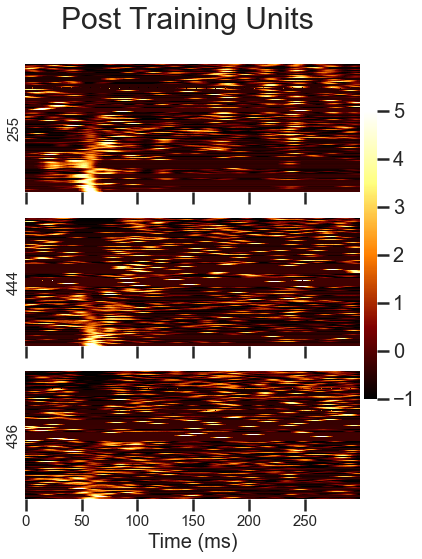

In [223]:
sp_dims = (6, 8) #(width, height)

f, ax = plt.subplots(3,1, sharex=True, figsize=sp_dims)
cbar_ax = f.add_axes([.91, .3, .03, .5])
cbar_ax.tick_params(labelsize=20)
f.suptitle('Post Training Units', fontsize=30)
v_max = 5


sns.heatmap(v1_hm2, cmap = 'afmhot', cbar_ax = cbar_ax,
                  xticklabels=False, yticklabels=False, vmax=v_max, center = 2, vmin = -1, robust = True,
           ax=ax[0])
ax[0].set_xlabel(' ', fontsize = 15.0)
ax[0].set_ylabel(v1_units, fontsize = 15.0)
# ax[0].set_ylabel('V1', fontsize = 20.0)


sns.heatmap(hip_hm2, cmap = 'afmhot',  cbar_ax = cbar_ax,
                  xticklabels=False, yticklabels=False, vmax=v_max, center = 2, vmin = -1, robust = True, 
            ax=ax[1])
ax[1].set_xlabel(' ', fontsize = 15.0)
ax[1].set_ylabel(hip_units, fontsize = 15.0)
# ax[1].set_ylabel('Hippocampus', fontsize = 20.0)


sns.heatmap(thal_hm2, cmap = 'afmhot',  cbar_ax = cbar_ax,
                  xticklabels=50, yticklabels=False, vmax=v_max, center = 2, vmin = -1, robust = True, 
            ax=ax[2])
ax[2].set_xlabel('Time (ms)', fontsize = 20.0)
ax[2].tick_params(labelsize=15)
ax[2].set_ylabel(thal_units, fontsize = 15.0)
# ax[2].set_ylabel('Thalamus', fontsize = 20.0)


# Heatmap of units in V1 and Hippo

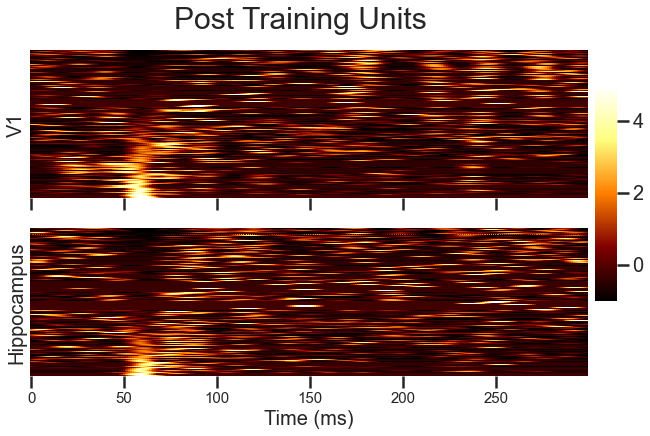

In [208]:
sp_dims = (10, 6) #(width, height)

f, ax = plt.subplots(2,1, sharex=True, figsize=sp_dims)
cbar_ax = f.add_axes([.91, .3, .03, .5])
cbar_ax.tick_params(labelsize=20)
f.suptitle('Post Training Units', fontsize=30)
v_max = 5


sns.heatmap(v1_hm2, cmap = 'afmhot', cbar_ax = cbar_ax, xticklabels=False, yticklabels=False, 
            vmax=v_max, center = 2, vmin = -1, robust = True, ax=ax[0])
ax[0].set_xlabel(' ', fontsize = 15.0)
# ax[0].set_ylabel(v1_units, fontsize = 15.0)
ax[0].set_ylabel('V1', fontsize = 20.0)


sns.heatmap(hip_hm2, cmap = 'afmhot',  cbar_ax = cbar_ax, xticklabels=50, yticklabels=False, 
            vmax=v_max, center = 2, vmin = -1, robust = True, ax=ax[1])
ax[1].set_xlabel(' ', fontsize = 15.0)
# ax[1].set_ylabel(hip_units, fontsize = 15.0)
ax[1].set_ylabel('Hippocampus', fontsize = 20.0)
ax[1].set_xlabel('Time (ms)', fontsize = 20.0)
ax[1].tick_params(labelsize=15)



# Change the end of this next line with a new file name!!
#plt.savefig(r"C:\Users\AChub_Lab\Desktop\zimmer94\Data\DATA_Figs\Neuropix\v1_TFbarplot_drift.pdf", transparent=True)

# Z-score of all regions

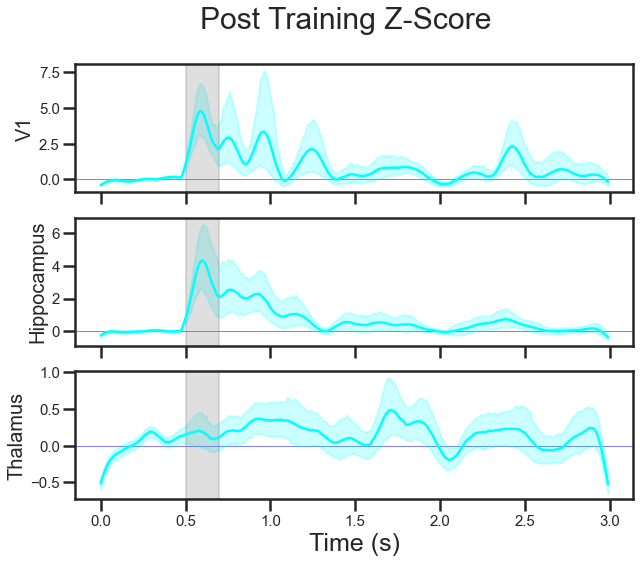

In [209]:
sp_dims = (10, 8) #(width, height)


f, ax = plt.subplots(3,1, sharex=True, figsize=sp_dims)
f.suptitle('Post Training Z-Score', fontsize=30)


f1 = sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = post_v1_df, color = 'Cyan', ax=ax[0])
ax[0].axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax[0].axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax[0].set_xlabel(' ', fontsize = 15.0)
ax[0].set_ylabel('V1', fontsize = 20.0)
ax[0].tick_params(labelsize=15)
#ax[0].set_ylim([-2, 2])


f2 = sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = post_hip_df, color = 'Cyan', ax=ax[1])
ax[1].axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax[1].axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax[1].set_xlabel(' ', fontsize = 15.0)
ax[1].set_ylabel('Hippocampus', fontsize = 20.0)
ax[1].tick_params(labelsize=15)
#ax[1].set_ylim([-2, 2])


f3 = sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = post_thal_df, color = 'Cyan', ax=ax[2])
ax[2].axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax[2].axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax[2].set_xlabel('Time (s)', fontsize = 25)
ax[2].set_ylabel('Thalamus', fontsize = 20.0)
ax[2].tick_params(labelsize=15)
#ax[2].set_ylim([-2, 2])




# Z-Score of V1 and Hippo

Text(0.5, 0, 'Time (s)')

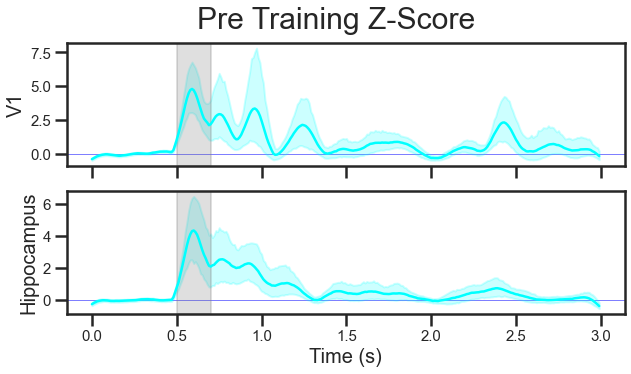

In [211]:
sp_dims = (10, 5) #(width, height)
y_lim = [-1.5, 1.5]

f, ax = plt.subplots(2,1, sharex=True, figsize=sp_dims)
f.suptitle('Pre Training Z-Score', fontsize=30)


f1 = sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = post_v1_df, color = 'Cyan', ax=ax[0])
ax[0].axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax[0].axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax[0].set_xlabel(' ', fontsize = 15.0)
ax[0].set_ylabel('V1', fontsize = 20.0)
ax[0].tick_params(labelsize=15)
#ax[0].set_ylim(y_lim)


f2 = sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = post_hip_df, color = 'Cyan', ax=ax[1])
ax[1].axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax[1].axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax[1].set_xlabel(' ', fontsize = 15.0)
ax[1].set_ylabel('Hippocampus', fontsize = 20.0)
ax[1].tick_params(labelsize=15)
#ax[1].set_ylim(y_lim)
ax[1].set_xlabel('Time (s)', fontsize = 20.0)



# Change the end of this next line with a new file name!!
#plt.savefig(r"C:\Users\AChub_Lab\Desktop\zimmer94\Data\DATA_Figs\Neuropix\v1_TFbarplot_drift.pdf", transparent=True)

# Plotting Heatmaps and Z-score together

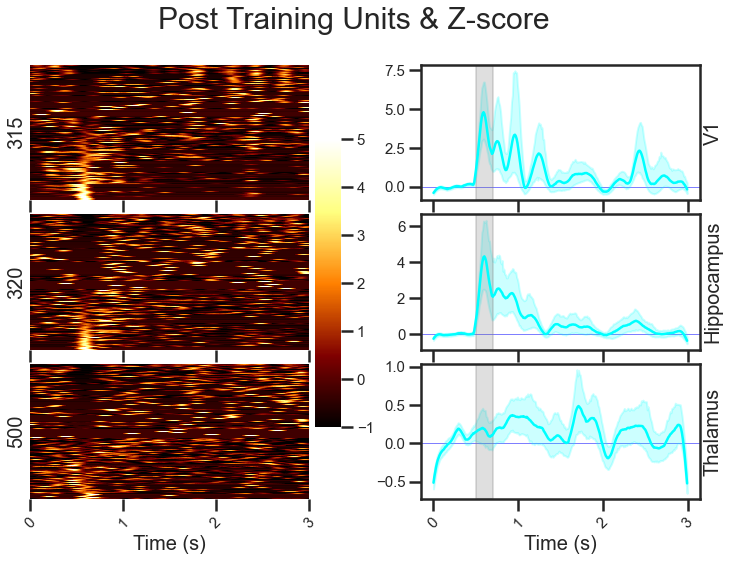

In [212]:
sp_dims = (12, 8) #(width, height)

f, ax = plt.subplots(3,2, sharex='col', figsize=sp_dims)
cbar_ax = f.add_axes([0.455, .25, .03, .5]) #left, bottom, width, height
cbar_ax.tick_params(labelsize=15)
f.suptitle('Post Training Units & Z-score', fontsize=30)

plt.subplots_adjust(wspace=0.4, #space between columns
                    hspace=0.1) #space between rows


ax1 = ax[0,0]; ax2 = ax[1,0]; ax3 = ax[2,0];
ax4 = ax[0,1]; ax5 = ax[1,1]; ax6 = ax[2,1];

v_span = [-1,5]


# Heatmaps

sns.heatmap(v1_hm2, cmap = 'afmhot', cbar_ax = cbar_ax, xticklabels=False, yticklabels=False, 
            vmax=v_span[1], center = 2, vmin = v_span[0], robust = True, ax=ax1)
ax1.set_xlabel(' ', fontsize = 15.0)
ax1.set_ylabel(v1_units, fontsize = 20)
ax1.set_xticks([0,100,200,300])

sns.heatmap(hip_hm2, cmap = 'afmhot',  cbar_ax = cbar_ax, xticklabels=False, yticklabels=False,
            vmax=v_span[1], center = 2, vmin = v_span[0], robust = True, ax=ax2)
ax2.set_xlabel(' ', fontsize = 15.0)
ax2.set_ylabel(hip_units, fontsize = 20)
ax2.set_xticks([0,100,200,300])

sns.heatmap(thal_hm2, cmap = 'afmhot',  cbar_ax = cbar_ax, xticklabels=50, yticklabels=False, 
            vmax=v_span[1], center = 2, vmin = v_span[0], robust = True, ax=ax3)
ax3.set_xlabel('Time (s)', fontsize = 20.0)
ax3.tick_params(labelsize=15)
ax3.set_ylabel(thal_units, fontsize = 20)
ax3.set_xticks([0,100,200,300])
ax3.set_xticklabels(['0','1','2','3'], rotation=45)


# Lineplots

sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = post_v1_df, color = 'Cyan', ax=ax4)
ax4.axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax4.axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax4.yaxis.set_label_position("right")
ax4.set_ylabel('V1', fontsize = 20)
ax4.tick_params(labelsize=15)

sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = post_hip_df, color = 'Cyan', ax=ax5)
ax5.axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax5.axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax5.yaxis.set_label_position("right")
ax5.set_ylabel('Hippocampus', fontsize = 20)
ax5.tick_params(labelsize=15)

sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = post_thal_df, color = 'Cyan', ax=ax6)
ax6.axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax6.axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax6.set_xlabel('Time (s)', fontsize = 20)
ax6.yaxis.set_label_position("right")
ax6.set_ylabel('Thalamus', fontsize = 20)
ax6.tick_params(axis='y', labelsize=15)
ax6.tick_params(axis='x', labelrotation=45, labelsize=15)



---

***

***

---

---

---